<a href="https://colab.research.google.com/github/josedanielisidororeyes/Natural_Language_Processing/blob/main/Tarea_Analisis_de_Texto_PLN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Nombre del Alumno: José Daniel Isidoro Reyes
##Matrícula: 261552
##Nombre de la Tarea: Análisis de texto
## Fecha: 28/02/2026


In [27]:
# Carga de librerías
import re
import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
!python -m spacy download es_core_news_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 78.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Texto Original

In [18]:
texto  = '''
En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes.

@Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.

Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.

El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital

Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial

y la inteligencia artificial aparecen repetidamente en los debates académicos.
'''

## Eliminación de URLS, correos, menciones y hastags

In [19]:
# Eliminación de urls
texto_cleaned = re.sub(r'https?://\S+|www\.\S+', '', texto)
# Eliminación de correos
texto_cleaned =  re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '', texto_cleaned)
# Eliminación de menciones
texto_cleaned =  re.sub(r'@\w+', '', texto_cleaned)
# Eliminación de  hashtags
texto_cleaned = re.sub(r'#\w+', '', texto_cleaned)

En esta etapa se eliminan urls, correos, menciones y hashtags debido a que no aportan ninguno contenido linguistico.  

## Normalización de Texto

In [20]:
# Normalización de texto

# Conversión a minúsculas
texto_cleaned =  texto_cleaned.lower()

# Eliminación de signos de puntuación
texto_cleaned =  re.sub(r'[^\w\s]', '', texto_cleaned)
texto_cleaned =  re.sub(r'\s+', ' ', texto_cleaned).strip()

En esta segunda etapa se normaliza el texto eliminando signos de puntuación, espacios adicionales y transformado el texto en minusculas para reducir la complejidad del vocabalario (tokens adicionales)

## Tokenización, Eliminación de Stopwords y Lematización

In [21]:
nlp =  spacy.load("es_core_news_sm")
doc =  nlp(texto_cleaned)
lemas  =  [token.lemma_  for token in doc if not token.is_stop and token.is_alpha]

Finalmente, en esta etapa se eliminan palabras comunes (stopwords) las cuales no tienen ningun contenido semantico propio. De igual manera, se transformar las palabras a su base gramtical  (lematización) con la finalidad de reducir el número de palabras y mejorar la precisión de conteos de palabras.

## Visualización

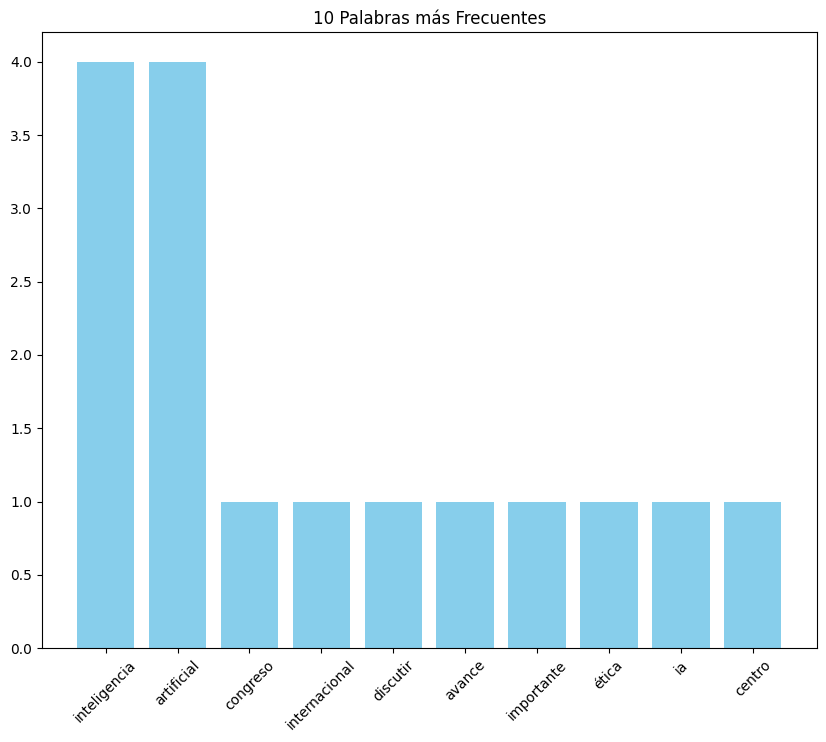

In [25]:
frecuencia  =  Counter(lemas)
palabras, conteos =  zip(*frecuencia.most_common(10))

plt.figure(figsize = (10, 8))
plt.bar(palabras, conteos, color  = 'skyblue')
plt.title('10 Palabras más Frecuentes')
plt.xticks(rotation = 45)
plt.show()

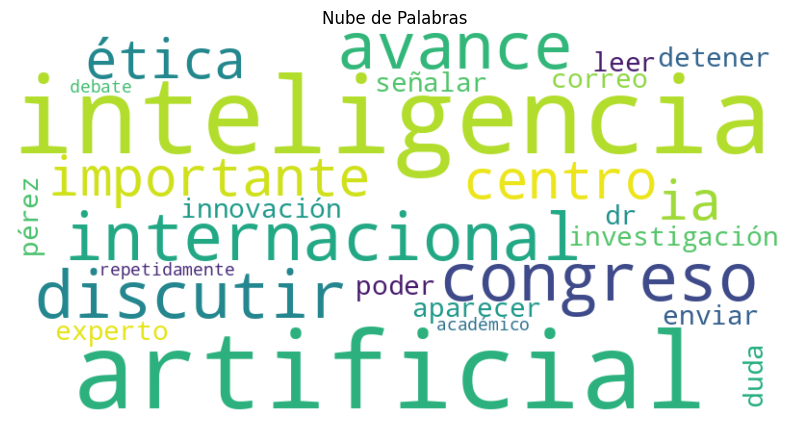

In [26]:
wordcloud =  WordCloud(width =  800, height = 400, background_color  = 'white').generate(" ".join(lemas))
plt.figure(figsize =  (10, 5))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.title('Nube de Palabras')
plt.show()

 A través de la nube de palabras es posible identificar que el texto trata predominantemente sobre inteligencia artificial y ética.